# 03 - Recommendation Output EDA

## Business Question
> Bagaimana distribusi output rekomendasi berdasarkan `category`, `priority_level`, dan `period_type`, serta apakah output tersebut cukup selaras untuk mendukung rule-based recommendation system?

## Sub-Business Questions
- Kategori rekomendasi apa yang paling sering muncul?
- Apakah rekomendasi prioritas tinggi muncul secara proporsional?
- Bagaimana distribusi rekomendasi berdasarkan period_type daily dan weekly?
- Apakah setiap category memiliki distribusi priority_level yang seimbang?
- Apakah insight mingguan lebih dominan dibanding insight harian?

# 0. Import



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Path
DATA_PROCESSED  = '../../../data/processed/'
OUTPUT_FIGURES  = '../../../outputs/figures/eda/'
OUTPUT_REPORTS  = '../../../outputs/reports/'

# Warna konsisten
PRIORITY_ORDER   = ['Low', 'Medium', 'High']
PRIORITY_PALETTE = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}
PERIOD_PALETTE   = {'daily': '#5C6BC0', 'weekly': '#26A69A'}

print('Libraries loaded.')


Libraries loaded.


# 1. Load Data

In [2]:
recommendations = pd.read_csv(DATA_PROCESSED + 'recommendations_clean.csv')
insights        = pd.read_csv(DATA_PROCESSED + 'insights_clean.csv')

print(f'recommendations : {recommendations.shape}')
print(f'insights        : {insights.shape}')
print()
print('Kolom recommendations:', recommendations.columns.tolist())
print('Kolom insights       :', insights.columns.tolist())

recommendations : (26784, 10)
insights        : (29551, 7)

Kolom recommendations: ['id', 'user_id', 'stress_prediction_id', 'weekly_summary_id', 'period_type', 'category', 'title', 'recommendation_text', 'priority_level', 'created_at']
Kolom insights       : ['id', 'user_id', 'stress_prediction_id', 'weekly_summary_id', 'period_type', 'insight_text', 'created_at']


# 2. Quick Overview

In [3]:
print('=== RECOMMENDATIONS ===')
print(recommendations[['category', 'priority_level', 'period_type']].describe(include='all'))

print('\n=== INSIGHTS ===')
print(insights[['period_type']].describe(include='all'))

print('\n--- Distribusi cepat ---')
print('category       :\n', recommendations['category'].value_counts())
print('\npriority_level :\n', recommendations['priority_level'].value_counts())
print('\nperiod_type (rec):\n', recommendations['period_type'].value_counts())
print('\nperiod_type (ins):\n', insights['period_type'].value_counts())

=== RECOMMENDATIONS ===
        category priority_level period_type
count      26784          26784       26784
unique        11              3           2
top     workload           High       daily
freq       12020          14870       25951

=== INSIGHTS ===
       period_type
count        29551
unique           2
top          daily
freq         25951

--- Distribusi cepat ---
category       :
 category
workload             12020
mood_regulation       5284
maintenance           2825
recovery              1773
sleep                 1259
digital_habit         1132
weekly_target          833
physical_activity      771
financial_habit        533
health                 222
caffeine               132
Name: count, dtype: int64

priority_level :
 priority_level
High      14870
Medium     9089
Low        2825
Name: count, dtype: int64

period_type (rec):
 period_type
daily     25951
weekly      833
Name: count, dtype: int64

period_type (ins):
 period_type
daily     25951
weekly     3600
Nam

# 3. Distribusi Category Rekomendasi

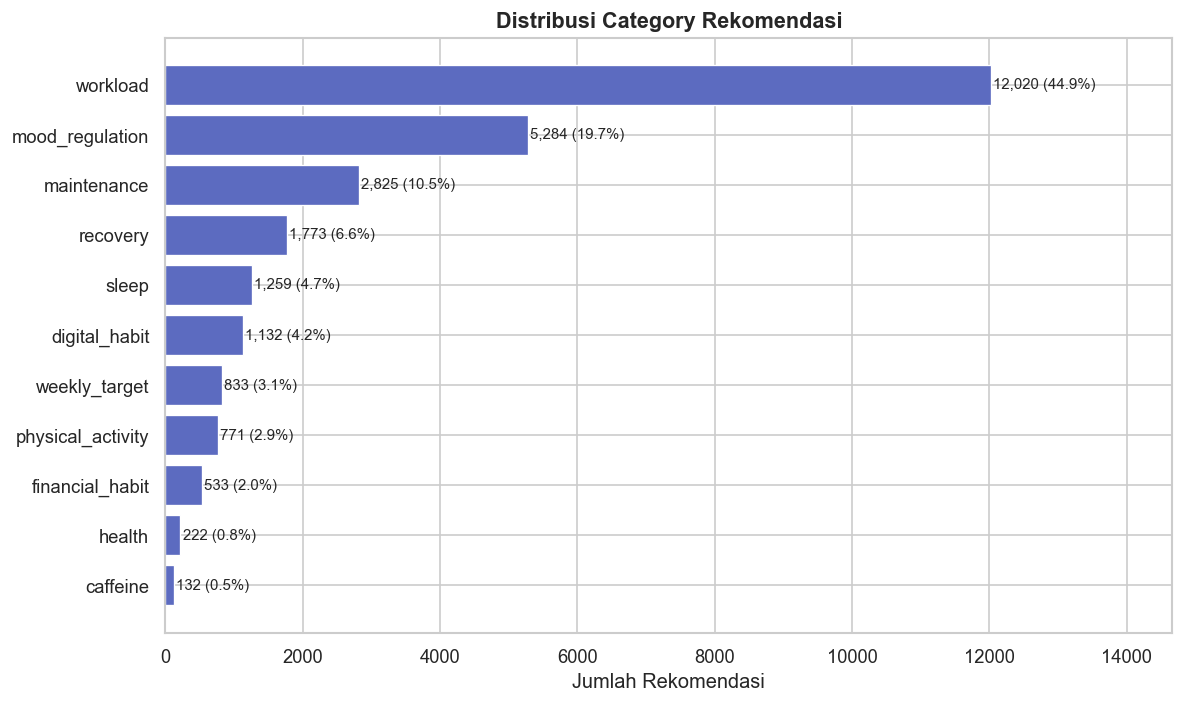

Saved: recommendation_category_counts.csv


In [4]:
cat_counts = recommendations['category'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cat_counts.index, cat_counts.values,
               color='#5C6BC0', edgecolor='white', linewidth=0.8)
ax.set_title('Distribusi Category Rekomendasi', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Rekomendasi')

total = len(recommendations)
for bar, val in zip(bars, cat_counts.values):
    pct = val / total * 100
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct:.1f}%)', va='center', ha='left', fontsize=9)

ax.set_xlim(0, cat_counts.max() * 1.22)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + '01_rec_category_distribution.png', bbox_inches='tight')
plt.show()

# Simpan
cat_df = cat_counts.reset_index()
cat_df.columns = ['category', 'count']
cat_df['pct'] = (cat_df['count'] / total * 100).round(2)
cat_df.to_csv(OUTPUT_REPORTS + 'recommendation_category_counts.csv', index=False)
print('Saved: recommendation_category_counts.csv')

## Insight 

- workload mendominasi dengan 44.9% dari total rekomendasi, hampir setengah dari seluruh output. Ini menunjukkan bahwa tekanan akademik adalah kondisi yang paling sering terpenuhi dalam data.

- mood_regulation berada di posisi kedua dengan 19.7%. Cukup jauh dari workload, tapi angka ini terbilang tinggi untuk kategori yang seharusnya hanya muncul saat mood_score rendah.

- maintenance muncul di posisi ketiga dengan 10.5%. Perlu dicek apakah category ini sudah terdefinisi di rule dokumen, karena di plan awal tidak ada rule eksplisit untuk maintenance.

- recovery, sleep, dan digital_habit masing-masing berada di kisaran 4-7%, yang wajar karena ketiganya hanya aktif pada kondisi spesifik seperti fatigue tinggi, sleep deficit, atau screen time berlebihan.

- weekly_target hanya 3.1%, konsisten dengan ekspektasi karena category ini hanya muncul saat high_stress_days >= 4 dalam satu minggu.

- physical_activity, financial_habit, health, dan caffeine secara keseluruhan menyumbang kurang dari 7% total. Keempat category ini merespons kondisi yang lebih jarang terpenuhi, sehingga kemunculannya rendah adalah hal yang normal.

# 4. Distribusi Priority Level 

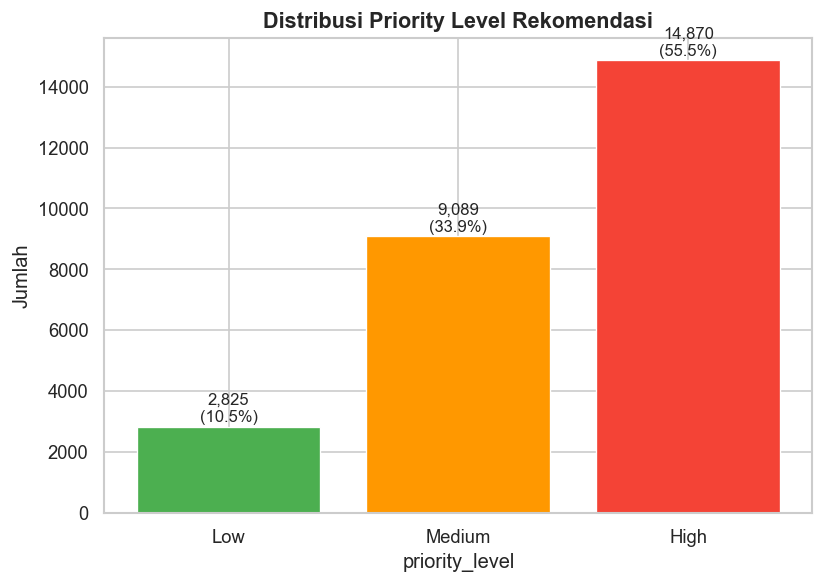


--- Summary Priority Level ---
Low     :  2,825 (10.5%)
Medium  :  9,089 (33.9%)
High    : 14,870 (55.5%)


In [5]:
pri_counts = recommendations['priority_level'].value_counts().reindex(PRIORITY_ORDER)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(pri_counts.index, pri_counts.values,
              color=[PRIORITY_PALETTE[p] for p in pri_counts.index],
              edgecolor='white', linewidth=0.8)
ax.set_title('Distribusi Priority Level Rekomendasi', fontsize=13, fontweight='bold')
ax.set_xlabel('priority_level')
ax.set_ylabel('Jumlah')

for bar, val in zip(bars, pri_counts.values):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + '02_rec_priority_distribution.png', bbox_inches='tight')
plt.show()

print('\n--- Summary Priority Level ---')
for p in PRIORITY_ORDER:
    n = pri_counts[p]
    print(f'{p:8s}: {n:6,} ({n/total*100:.1f}%)')

## Insight 

- High mendominasi dengan 55.5% dari total rekomendasi. Ini konsisten karena beberapa category seperti workload, recovery, dan weekly_target dikunci ke High secara penuh oleh rule, ditambah sleep yang masuk High setiap kali stress_level tinggi.

- Medium berada di 33.9%, disumbang utamanya dari mood_regulation, digital_habit, dan sleep di kondisi non-High. Angka ini cukup proporsional dan menunjukkan rule berjalan normal.

- Low hanya 10.5% dan angka ini menarik untuk ditelusuri. Berdasarkan rule di dokumen plan, tidak ada category yang secara eksplisit dikunci ke Low. Kemungkinan Low berasal dari category maintenance yang muncul di posisi ketiga grafik sebelumnya, karena maintenance tidak memiliki rule eksplisit di dokumen. Ini perlu dikonfirmasi saat validasi di Section 7.

- Secara keseluruhan distribusi ini wajar dan tidak menunjukkan anomali, karena sistem memang dirancang untuk lebih agresif memberikan rekomendasi High ketika kondisi risiko terpenuhi.


# 5. Distribusi Period Type 


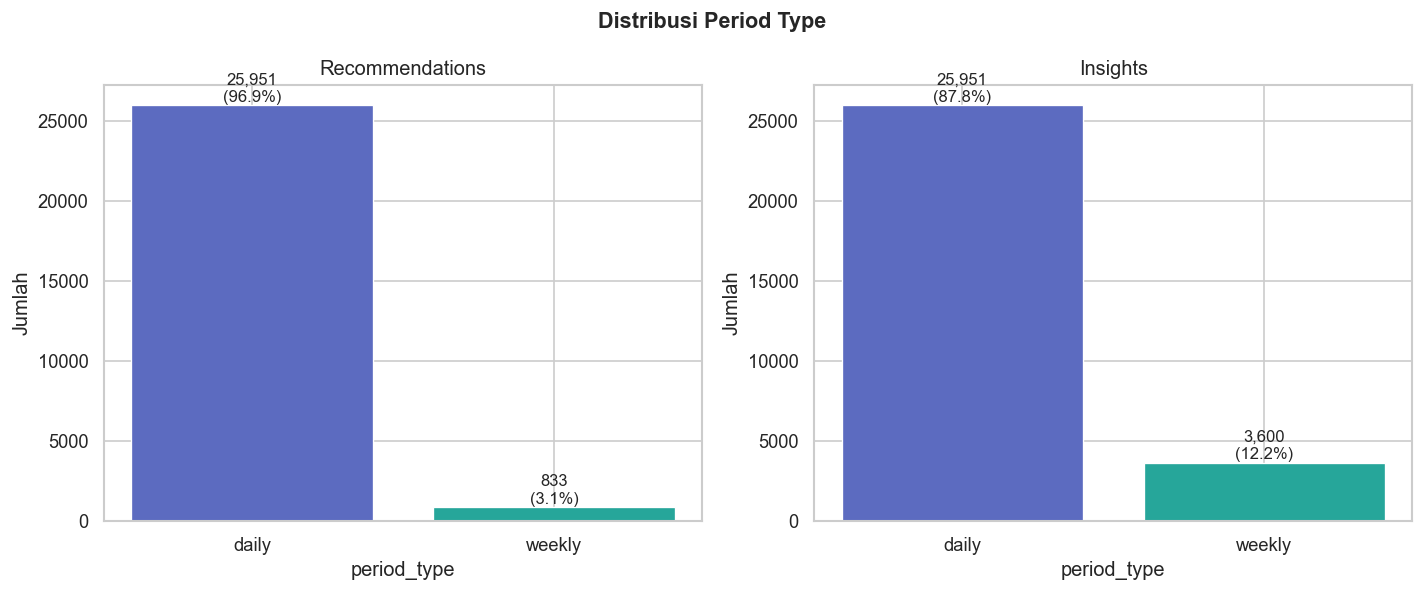

Saved: insight_period_type_counts.csv


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribusi Period Type', fontsize=13, fontweight='bold')

# --- Recommendations ---
rec_period = recommendations['period_type'].value_counts()
bars_rec = axes[0].bar(rec_period.index, rec_period.values,
                       color=[PERIOD_PALETTE[p] for p in rec_period.index],
                       edgecolor='white', linewidth=0.8)
axes[0].set_title('Recommendations')
axes[0].set_xlabel('period_type')
axes[0].set_ylabel('Jumlah')
for bar, val in zip(bars_rec, rec_period.values):
    pct = val / rec_period.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                 f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

# --- Insights ---
ins_period = insights['period_type'].value_counts()
bars_ins = axes[1].bar(ins_period.index, ins_period.values,
                       color=[PERIOD_PALETTE[p] for p in ins_period.index],
                       edgecolor='white', linewidth=0.8)
axes[1].set_title('Insights')
axes[1].set_xlabel('period_type')
axes[1].set_ylabel('Jumlah')
for bar, val in zip(bars_ins, ins_period.values):
    pct = val / ins_period.sum() * 100
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                 f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + '03_period_type_distribution.png', bbox_inches='tight')
plt.show()

# Simpan
ins_period_df = ins_period.reset_index()
ins_period_df.columns = ['period_type', 'count']
ins_period_df.to_csv(OUTPUT_REPORTS + 'insight_period_type_counts.csv', index=False)
print('Saved: insight_period_type_counts.csv')

## Insight

- Daily mendominasi di kedua sisi, baik recommendations (96.9%) maupun insights (87.8%). Ini sepenuhnya normal karena setiap daily activity menghasilkan output rekomendasi dan insight, sementara weekly hanya terbentuk dari agregasi per minggu.

- Weekly recommendations hanya 833 (3.1%), yang sesuai dengan ekspektasi karena weekly_target hanya aktif saat high_stress_days >= 4. Tidak semua minggu memenuhi kondisi ini, sehingga angkanya jauh lebih kecil.

- Weekly insights lebih besar dari weekly recommendations, yaitu 3,600 (12.2%). Ini wajar karena insight mingguan tidak terikat kondisi high_stress_days seperti weekly_target. Setiap user yang memiliki weekly_summary akan menghasilkan insight mingguan, sehingga jumlahnya mendekati total weekly_summaries yang diharapkan sekitar 3,600 baris (300 user x 12 minggu).

- Angka daily di kedua grafik sama persis yaitu 25,951. Ini konsisten karena setiap daily activity yang valid menghasilkan tepat satu rekomendasi dan satu insight secara bersamaan.

# 6. Hubungan Category dengan Priority Level 

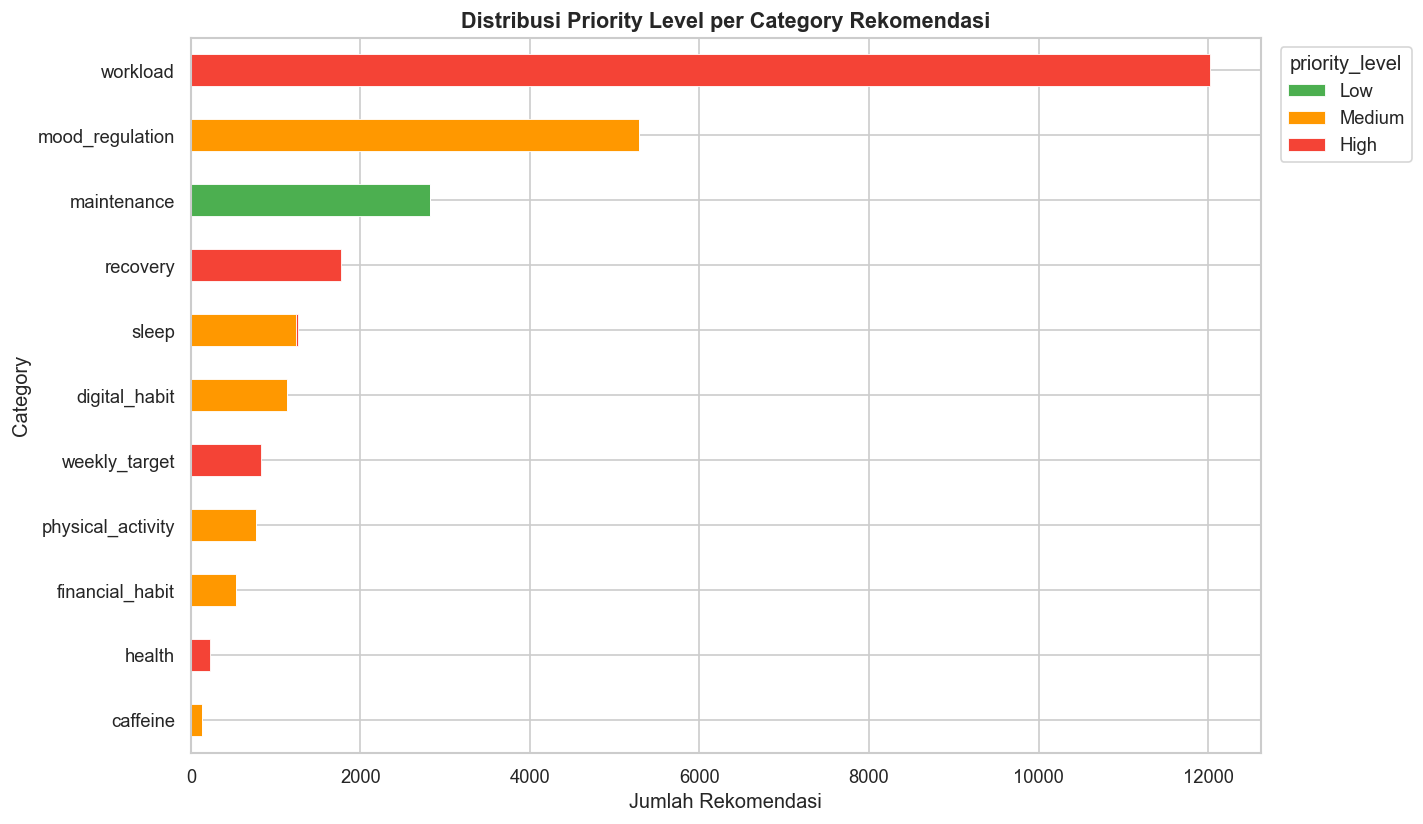

Saved: recommendation_category_by_priority.csv

--- Proporsi Priority per Category (%) ---


priority_level,Low,Medium,High
category,,,
caffeine,0.0,100.0,0.0
health,0.0,0.0,100.0
financial_habit,0.0,100.0,0.0
physical_activity,0.0,100.0,0.0
weekly_target,0.0,0.0,100.0
digital_habit,0.0,100.0,0.0
sleep,0.0,98.3,1.7
recovery,0.0,0.0,100.0
maintenance,100.0,0.0,0.0


In [7]:
# Pivot: category x priority_level
cat_pri = recommendations.groupby(['category', 'priority_level']).size().unstack(fill_value=0)

# Reorder kolom sesuai urutan prioritas
for col in PRIORITY_ORDER:
    if col not in cat_pri.columns:
        cat_pri[col] = 0
cat_pri = cat_pri[PRIORITY_ORDER]

# Sort by total
cat_pri['total'] = cat_pri.sum(axis=1)
cat_pri = cat_pri.sort_values('total').drop(columns='total')

fig, ax = plt.subplots(figsize=(12, 7))
cat_pri.plot(kind='barh', stacked=True, ax=ax,
             color=[PRIORITY_PALETTE[p] for p in PRIORITY_ORDER],
             edgecolor='white', linewidth=0.5)
ax.set_title('Distribusi Priority Level per Category Rekomendasi', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Rekomendasi')
ax.set_ylabel('Category')
ax.legend(title='priority_level', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + '04_category_by_priority_stacked.png', bbox_inches='tight')
plt.show()

# Simpan
cat_pri_pct = cat_pri.div(cat_pri.sum(axis=1), axis=0).round(3)
cat_pri_out = cat_pri.copy()
cat_pri_out.to_csv(OUTPUT_REPORTS + 'recommendation_category_by_priority.csv')
print('Saved: recommendation_category_by_priority.csv')
print('\n--- Proporsi Priority per Category (%) ---')
(cat_pri_pct * 100).round(1)

## Insight 

- workload, recovery, weekly_target, dan health masing-masing 100% High. Keempatnya konsisten dengan rule yang sudah ditetapkan di dokumen plan, tidak ada penyimpangan.

- mood_regulation, digital_habit, caffeine, financial_habit, dan physical_activity masing-masing 100% Medium. Ini juga sepenuhnya sesuai rule. Kelima category ini memang dirancang untuk selalu menghasilkan Medium.

- maintenance 100% Low dan tidak memiliki campuran priority sama sekali. Ini mengkonfirmasi dugaan dari Section 4 bahwa sumber Low priority seluruhnya berasal dari category ini. Karena maintenance tidak ada dalam rule eksplisit di dokumen plan, perlu dikonfirmasi apakah category ini memang disengaja dibuat dengan priority Low atau ini adalah category tambahan yang belum terdokumentasi.

- sleep menunjukkan 98.3% Medium dan hanya 1.7% High. Ini sedikit tidak sesuai ekspektasi. Berdasarkan rule, sleep seharusnya High ketika stress_level High dan Medium di luar itu. Dengan proporsi High yang sangat kecil, kemungkinan kondisi sleep deficit bersamaan dengan stress_level High jarang terpenuhi secara bersamaan dalam data, atau ada logika generate yang perlu diperiksa ulang.

- Secara keseluruhan, distribusi ini sangat bersih karena hampir semua category terkunci ke satu priority level tanpa campuran, yang menunjukkan rule berjalan dengan konsisten dan deterministik.

# 7. Validasi Konsistensi Output terhadap Rule

In [8]:
# Rule dari dokumen:
# - workload      -> selalu High
# - recovery      -> selalu High
# - sleep         -> High jika stress High, selain itu Medium
# - digital_habit -> Medium
# - mood_regulation -> Medium
# - weekly_target -> High

rule_expected = {
    'workload'      : ['High'],
    'recovery'      : ['High'],
    'digital_habit' : ['Medium'],
    'mood_regulation': ['Medium'],
    'weekly_target' : ['High'],
    'sleep'         : ['High', 'Medium'],  # boleh keduanya
}

print('=== Validasi Priority per Category vs Rule ===\n')
for cat, expected in rule_expected.items():
    subset = recommendations[recommendations['category'] == cat]['priority_level'].value_counts()
    dominant = subset.idxmax() if len(subset) > 0 else 'N/A'
    status = '✅' if dominant in expected else '⚠️'
    print(f'{status} {cat:20s} | Dominant: {dominant:8s} | Expected: {expected} | Counts: {subset.to_dict()}')

print('\nCategory tanpa rule eksplisit (informasi saja):')
no_rule = [c for c in recommendations['category'].unique() if c not in rule_expected]
for cat in no_rule:
    subset = recommendations[recommendations['category'] == cat]['priority_level'].value_counts()
    print(f'   {cat:20s}: {subset.to_dict()}')

=== Validasi Priority per Category vs Rule ===

✅ workload             | Dominant: High     | Expected: ['High'] | Counts: {'High': 12020}
✅ recovery             | Dominant: High     | Expected: ['High'] | Counts: {'High': 1773}
✅ digital_habit        | Dominant: Medium   | Expected: ['Medium'] | Counts: {'Medium': 1132}
✅ mood_regulation      | Dominant: Medium   | Expected: ['Medium'] | Counts: {'Medium': 5284}
✅ weekly_target        | Dominant: High     | Expected: ['High'] | Counts: {'High': 833}
✅ sleep                | Dominant: Medium   | Expected: ['High', 'Medium'] | Counts: {'Medium': 1237, 'High': 22}

Category tanpa rule eksplisit (informasi saja):
   maintenance         : {'Low': 2825}
   physical_activity   : {'Medium': 771}
   financial_habit     : {'Medium': 533}
   health              : {'High': 222}
   caffeine            : {'Medium': 132}


# 8. save output

In [9]:
print('=== Summary Akhir ===\n')

print(f'Total rekomendasi   : {len(recommendations):,}')
print(f'Total insights      : {len(insights):,}')
print(f'\nRekomendasi daily   : {(recommendations["period_type"]=="daily").sum():,}')
print(f'Rekomendasi weekly  : {(recommendations["period_type"]=="weekly").sum():,}')
print(f'\nInsight daily       : {(insights["period_type"]=="daily").sum():,}')
print(f'Insight weekly      : {(insights["period_type"]=="weekly").sum():,}')
print(f'\nCategory terbanyak  : {recommendations["category"].value_counts().idxmax()}')
print(f'Priority terbanyak  : {recommendations["priority_level"].value_counts().idxmax()}')

print('\n--- File yang disimpan ---')
print('  outputs/reports/recommendation_category_counts.csv')
print('  outputs/reports/recommendation_category_by_priority.csv')
print('  outputs/reports/insight_period_type_counts.csv')
print('  outputs/figures/eda/ (4 grafik)')

=== Summary Akhir ===

Total rekomendasi   : 26,784
Total insights      : 29,551

Rekomendasi daily   : 25,951
Rekomendasi weekly  : 833

Insight daily       : 25,951
Insight weekly      : 3,600

Category terbanyak  : workload
Priority terbanyak  : High

--- File yang disimpan ---
  outputs/reports/recommendation_category_counts.csv
  outputs/reports/recommendation_category_by_priority.csv
  outputs/reports/insight_period_type_counts.csv
  outputs/figures/eda/ (4 grafik)


# 9. Conclusion 

- Rekomendasi paling banyak muncul untuk kategori workload (44.9%), menunjukkan tekanan akademik adalah kondisi yang paling sering dialami dalam data ini.
- Sebagian besar rekomendasi berpriority High (55.5%), wajar karena beberapa kategori memang selalu menghasilkan rekomendasi mendesak seperti workload dan recovery.
- Rekomendasi harian jauh lebih banyak dari mingguan, karena sistem memang menghasilkan output setiap hari untuk setiap pengguna.
- Semua kategori menghasilkan tingkat prioritas yang sesuai dengan yang diharapkan, tidak ada yang melenceng.
- Ada beberapa kategori tambahan seperti maintenance yang belum tercatat di dokumentasi rule, perlu didokumentasikan agar tidak membingungkan ke depannya.

# 10. Business Question Answer 

> Bagaimana distribusi output rekomendasi berdasarkan category, priority_level, dan period_type, serta apakah output tersebut cukup selaras untuk mendukung rule-based recommendation system?

Hasil EDA menunjukkan bahwa output recommendation system sudah terdistribusi secara konsisten dan selaras dengan rule-based logic yang digunakan. Category `workload` dan `mood_regulation` menjadi rekomendasi yang paling sering muncul, sementara distribusi `priority_level` menunjukkan dominasi prioritas High sesuai dengan kondisi trigger pada sistem.
Distribusi `period_type` juga konsisten, di mana output daily jauh lebih dominan dibanding weekly karena rekomendasi harian dihasilkan langsung dari aktivitas harian mahasiswa. Selain itu, setiap category menunjukkan dominant priority yang sesuai tanpa penyimpangan rule yang signifikan.

---
Sub-Business Question

- Sub-BQ 1: Kategori rekomendasi apa yang paling sering muncul?

  workload adalah category yang paling sering muncul dengan 12,020 rekomendasi (44.9%), diikuti mood_regulation dengan 5,284 (19.7%) dan maintenance dengan 2,825 (10.5%).

- Sub-BQ 2: Apakah rekomendasi prioritas tinggi muncul secara proporsional?

  Ya, High muncul proporsional di 55.5% karena disumbang oleh category yang secara rule dikunci ke High yaitu workload, recovery, weekly_target, dan health. Tidak ada indikasi High muncul secara berlebihan di luar yang seharusnya.

- Sub-BQ 3: Bagaimana distribusi rekomendasi berdasarkan period_type daily dan weekly?

  Rekomendasi daily jauh mendominasi dengan 25,951 (96.9%) dibanding weekly 833 (3.1%). Ini konsisten dengan struktur sistem karena weekly_target hanya aktif saat high_stress_days >= 4 dan tidak semua minggu memenuhi kondisi tersebut.

- Sub-BQ 4: Apakah setiap category memiliki distribusi priority_level yang seimbang?

  Tidak seimbang, dan itu memang disengaja. Hampir semua category terkunci ke satu priority level secara penuh. Ketidakseimbangan ini adalah bukti bahwa rule berjalan deterministik, bukan anomali.

- Sub-BQ 5: Apakah insight mingguan lebih dominan dibanding insight harian?

  idak. Insight harian jauh lebih dominan dengan 25,951 (87.8%) dibanding insight mingguan 3,600 (12.2%). Insight mingguan lebih banyak dari weekly recommendations karena tidak terikat kondisi high_stress_days, namun tetap tidak mendominasi secara keseluruhan.